In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [33]:
df = pd.read_csv("/Users/cyriaque/timeseries-arma-sarima-forecast/serie", sep= " ", header=None, names=["t", "Xt"])

In [6]:
df.head()


,1 4.26066519376672
0,2 3.51995202082366
1,3 3.11686737656048
2,4 3.89322145106253
3,5 2.66968938000672
4,6 2.47965600327938


In [7]:
df.dtypes

1 4.26066519376672    str
dtype: object

In [34]:
df["Xt"]=df["Xt"].astype(float)

In [17]:
df.dtypes

t          int64
value    float64
dtype: object

In [8]:
df.shape

(999, 1)

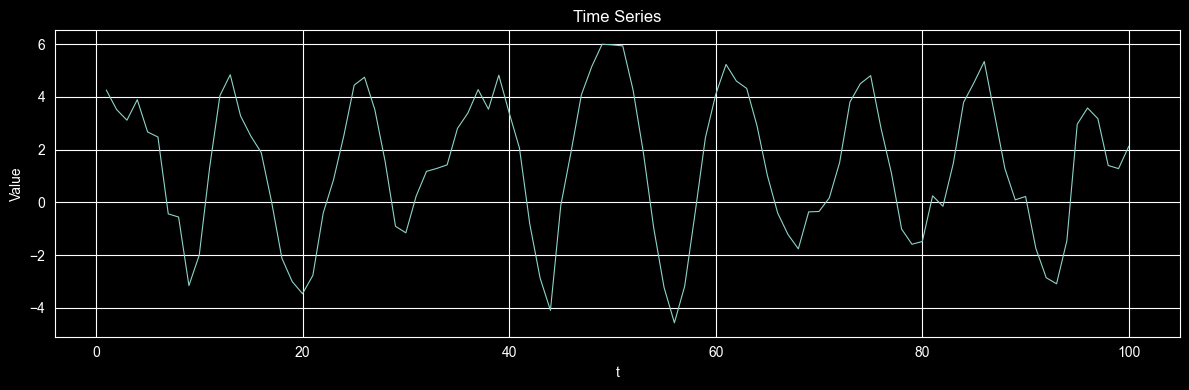

In [101]:
plt.figure(figsize=(12, 4))
plt.plot(df["t"][:100], df["Xt"][:100], linewidth=0.8)
plt.title("Time Series")
plt.xlabel("t")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

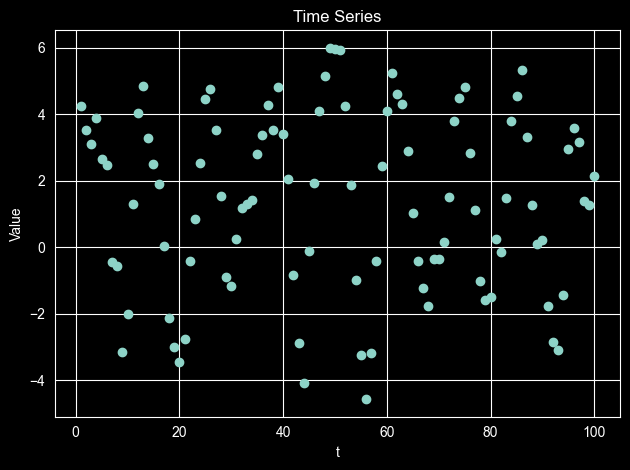

In [99]:
plt.scatter(df["t"][:100], df["Xt"][:100])
plt.title("Time Series")
plt.xlabel("t")
plt.ylabel("Value")
plt.tight_layout()
plt.show()


Considering only 100 observations we cannot observe any tendency.

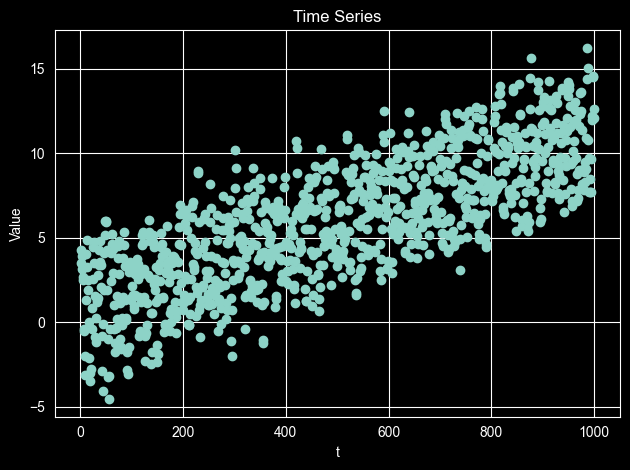

In [102]:
plt.scatter(df["t"], df["Xt"])
plt.title("Time Series")
plt.xlabel("t")
plt.ylabel("Value")
plt.tight_layout()
plt.show()


However with all the observations there is clearly a tendency.

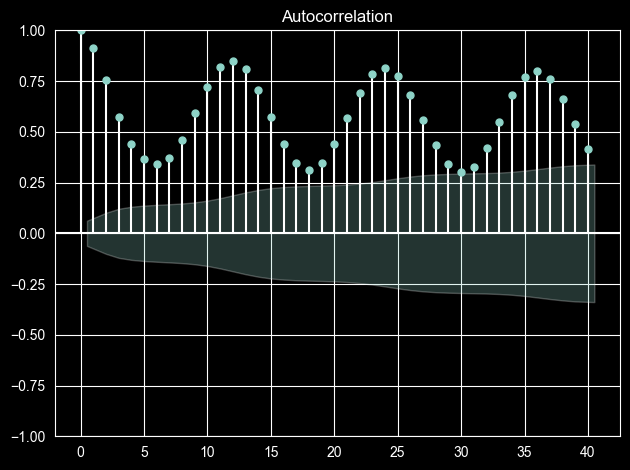

In [49]:
plot_acf(df["Xt"], lags=40)
plt.tight_layout()
plt.show()

slow decay: the ACF decreases very slowly and and stay well above the confidence band for all 40 lag, so we can assume that it is a non stationary series.

Periodic pattern : The ACF goes up and down which suggest a seasonality in the series.

No quick drop to zero : An ARMA would have an ACF dropping to zero exponentially quickly. That is not the case here which suggest non-stationarity.
Mathematically it probably means that the series has a unit root.

Since ACF decays slowly we can try to differentiate (I-B)^d Xt until the ACF function decays quickly


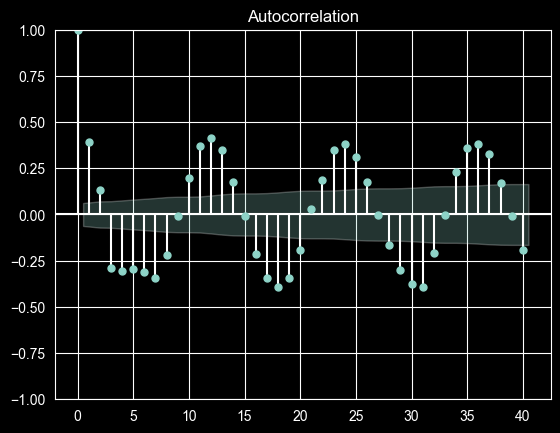

In [87]:
diff1_Xt = df["Xt"].diff(1).dropna()
plot_acf(diff1_Xt, lags=40)
plt.show()

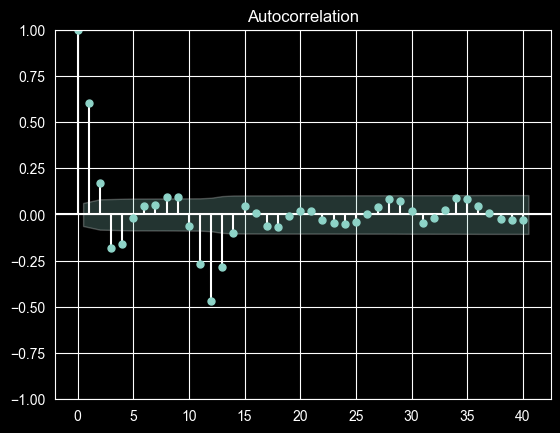

In [90]:
diff12_Xt = df["Xt"].diff(12).dropna()
plot_acf(diff12_Xt, lags=40)
plt.show()

We can observe that by differentiating 1,2,3,4 times,... doesn't change anything. But with 11,12 and 13 so we're probably not dealing with an ARIMA(p,d,q) but with a SARIMA(p,d,q)(P,D,Q)[12]

An other method to see that would have been with the one of Dickey and Fuller.


H0 : The series has a unit root --> non-stationary


H1 : The series is stationary

In [106]:
result = adfuller(df["Xt"])
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF statistic: -1.0171
p-value: 0.7470


Here the p-value is greater than 0.05 so we can reject H0. Hence the series is likely non-stationary which means that it cannot be estimate by an ARMA, we need an ARIMA or a SARIMA, this is coherent with have we have observe on the ACF graphics.
